In [ ]:
import pandas as pd
import polars as pl

ANNOTATION_PATHS = {
    "PLSDB": "data/plsdb_gene_annotations.tsv",
    "IMG/PR": "data/imgpr_gene_annotations.tsv",
}

plsdb_metadata = pl.read_excel(
    "data/plsdb_plasmid-host_metadata_with_taxonomy.xlsx",
    columns=["plasmid_seqid", "representative"],
    infer_schema_length=0,
)
imgpr_metadata = pl.read_excel(
    "data/imgpr_plasmid-host_metadata.xlsx",
    columns=["plasmid_seqid", "representative", "drop"],
    infer_schema_length=0,
)

SOURCE_COLUMNS = [
    "seqid", "prot_id", "strand", "merged_type", "merged_operon",
    "Antidefense_type", "Gene_symbol", "integrase_type",
]
DICT_COLUMNS = [
    "dataset", "prot_id", "merged_type", "Antidefense_type",
    "Gene_symbol", "integrase_type",
]


def scan_gene_annotations(path, dataset, plasmids):
    """Lazily read and normalize only the fields required by this analysis."""
    scan = pl.scan_csv(
        path,
        separator="\t",
        infer_schema_length=0,
        null_values="",
        low_memory=True,
    )
    raw_columns = scan.collect_schema().names()
    normalized = {column.replace(" ", "_"): column for column in raw_columns}
    missing = sorted(set(SOURCE_COLUMNS) - set(normalized))
    print(f"{dataset}: missing columns filled with null: {missing}")

    expressions = [
        pl.col(normalized[column]).alias(column)
        if column in normalized
        else pl.lit(None, dtype=pl.String).alias(column)
        for column in SOURCE_COLUMNS
    ]
    seqid_expression = (
        pl.col("seqid").str.extract(r"^([^|]+)", 1).alias("seqid")
        if dataset == "IMG/PR"
        else pl.col("seqid")
    )
    return (
        scan.select(expressions)
        .with_columns(seqid_expression)
        .join(plasmids.lazy(), on="seqid", how="semi")
        .with_columns(
            pl.lit(dataset).alias("dataset"),
            pl.col("prot_id")
            .str.extract(r"_(\d+)$", 1)
            .cast(pl.Int64)
            .alias("gene_order"),
        )
    )

PLSDB: retaining 29,831 plasmids
IMG/PR: retaining 439,209 plasmids


In [2]:
from collections import Counter
import time

WINDOW = 20
ENRICHMENT_WINDOW = 5
ENRICHMENT_CONTEXT_WINDOW = 20
POSITIONS = [*range(-WINDOW, 0), *range(1, WINDOW + 1)]
ENRICHMENT_CONTEXT_POSITIONS = [
    *range(-ENRICHMENT_CONTEXT_WINDOW, 0),
    *range(1, ENRICHMENT_CONTEXT_WINDOW + 1),
]
ANCHOR_COLUMNS = ["dataset", "seqid", "anchor_operon"]

started = time.perf_counter()
genes = pl.concat(
    [
        scan_gene_annotations(path, dataset, retained_plasmids[dataset])
        for dataset, path in ANNOTATION_PATHS.items()
    ],
    how="vertical",
)

defense_anchors = (
    genes.filter(pl.col("merged_operon").is_not_null())
    .group_by(["dataset", "seqid", "merged_operon"])
    .agg(
        pl.col("gene_order").min().alias("anchor_start"),
        pl.col("gene_order").max().alias("anchor_end"),
        pl.col("strand").drop_nulls().first().alias("anchor_strand"),
        pl.col("merged_type").is_not_null().any().alias("is_defense"),
    )
    .filter(pl.col("is_defense"))
    .drop("is_defense")
    .rename({"merged_operon": "anchor_operon"})
)

offsets = pl.DataFrame({"relative_position": POSITIONS}).lazy()
candidate_neighbors = (
    defense_anchors.join(offsets, how="cross")
    .with_columns(
        pl.when(pl.col("anchor_strand") == "+")
        .then(
            pl.when(pl.col("relative_position") < 0)
            .then(pl.col("anchor_start") + pl.col("relative_position"))
            .otherwise(pl.col("anchor_end") + pl.col("relative_position"))
        )
        .otherwise(
            pl.when(pl.col("relative_position") > 0)
            .then(pl.col("anchor_start") - pl.col("relative_position"))
            .otherwise(pl.col("anchor_end") - pl.col("relative_position"))
        )
        .alias("target_gene_order")
    )
    .filter(
        (pl.col("target_gene_order") < pl.col("anchor_start"))
        | (pl.col("target_gene_order") > pl.col("anchor_end"))
    )
)

matched_neighbors = (
    candidate_neighbors.join(
        genes.select(
            [
                "dataset", "seqid", "gene_order", *DICT_COLUMNS[1:],
                pl.col("merged_operon").alias("neighbor_operon"),
            ]
        ),
        left_on=["dataset", "seqid", "target_gene_order"],
        right_on=["dataset", "seqid", "gene_order"],
        how="inner",
    )
    .filter(
        pl.col("neighbor_operon").is_null()
        | (pl.col("neighbor_operon") != pl.col("anchor_operon"))
    )
    .select(
        [*ANCHOR_COLUMNS, "relative_position", *DICT_COLUMNS[1:]]
    )
    .collect(engine="streaming")
    .group_by(
        [*ANCHOR_COLUMNS, "relative_position", "prot_id"],
        maintain_order=True,
    )
    .agg(
        [
            pl.col(column).drop_nulls().first().alias(column)
            for column in DICT_COLUMNS[2:]
        ]
    )
)

defense_anchor_table = (
    defense_anchors.select(ANCHOR_COLUMNS)
    .collect(engine="streaming")
)
total_defense_anchors = defense_anchor_table.height

coverage_counts = (
    matched_neighbors.group_by("relative_position")
    .agg(
        pl.struct(ANCHOR_COLUMNS).n_unique().alias("n_defense_systems")
    )
)
neighbor_coverage = pd.DataFrame(
    pl.DataFrame({"position": POSITIONS})
    .join(
        coverage_counts.rename({"relative_position": "position"}),
        on="position",
        how="left",
    )
    .with_columns(
        pl.col("n_defense_systems").fill_null(0),
        (
            100
            * pl.col("n_defense_systems").fill_null(0)
            / total_defense_anchors
        ).alias("coverage_pct"),
    )
    .sort("position")
    .to_dicts()
)

enrichment_context_neighbors = matched_neighbors.filter(
    pl.col("relative_position").abs() <= ENRICHMENT_CONTEXT_WINDOW
)
enrichment_context_anchors = (
    enrichment_context_neighbors.group_by(ANCHOR_COLUMNS)
    .agg(
        pl.col("relative_position").n_unique().alias("n_positions")
    )
    .filter(pl.col("n_positions") == len(ENRICHMENT_CONTEXT_POSITIONS))
    .select(ANCHOR_COLUMNS)
)
enrichment_neighbors = enrichment_context_neighbors.join(
    enrichment_context_anchors,
    on=ANCHOR_COLUMNS,
    how="semi",
)
enrichment_context_anchor_count = enrichment_context_anchors.height

enrichment_position_counts = (
    enrichment_neighbors.group_by("relative_position")
    .agg(
        pl.struct(ANCHOR_COLUMNS).n_unique().alias("n_defense_systems")
    )
)
assert enrichment_position_counts.height == len(ENRICHMENT_CONTEXT_POSITIONS)
assert enrichment_position_counts["n_defense_systems"].min() == enrichment_context_anchor_count
assert enrichment_position_counts["n_defense_systems"].max() == enrichment_context_anchor_count


def build_neighbor_dictionary(neighbors):
    grouped = (
        neighbors.group_by("relative_position")
        .agg([pl.col(column) for column in DICT_COLUMNS])
    )
    output = {
        position: {column: [] for column in DICT_COLUMNS}
        for position in POSITIONS
    }
    for row in grouped.iter_rows(named=True):
        position = int(row.pop("relative_position"))
        output[position] = row
    return {"defense": output}


final_dicts_stranded = build_neighbor_dictionary(matched_neighbors)
enrichment_dicts_stranded = build_neighbor_dictionary(enrichment_neighbors)

dataset_counts = Counter(
    dataset
    for payload in final_dicts_stranded["defense"].values()
    for dataset in payload["dataset"]
)
elapsed = time.perf_counter() - started
print(f"Built defense-only stranded dictionary in {elapsed / 60:.1f} minutes")
print(f"Defense systems: {total_defense_anchors:,}")
print(
    f"Defense systems with full ±{ENRICHMENT_CONTEXT_WINDOW}-gene context: "
    f"{enrichment_context_anchor_count:,} "
    f"({100 * enrichment_context_anchor_count / total_defense_anchors:.1f}%)"
)
print("Neighbor rows by source:", dict(dataset_counts))


PLSDB: missing columns filled with null: []
IMG/PR: missing columns filled with null: []
Built defense-only stranded dictionary in 0.3 minutes
Defense systems: 141,930
Defense systems with full ±20-gene context: 38,595 (27.2%)
Neighbor rows by source: {'PLSDB': 898666, 'IMG/PR': 2806270}


In [3]:
PROMGE_COMPOSITE_CLASSES = {
    "IS/Tn": {
        'cas1_s1', 'huh_y1_s1', 'huh_y2_s1', 'ser_tn_s1',
        'Transposase_20_s1', 'Transposase_mut_s1', 'DDE_Tnp_ISL3_s1',
        'OrfB_IS605_s1', 'DDE_Tnp_IS240_s1', 'DDE_Tnp_1_2_s1',
        'Tn7_Tnp_TnsA_N_s1', 'DDE_Tnp_Tn3_s1', 'DDE_Tnp_1_3_s1',
        'Transposase_31_s1', 'DDE_Tnp_IS66_s1', 'DDE_Tnp_IS1595_s1',
        'PDDEXK_2_s1', 'Transposase_21_s1', 'DDE_3_s1', 'DDE_Tnp_1_s1',
        'DDE_Tnp_4_s1', 'DDE_Tnp_1_4_s1', 'DDE_5_s1', 'DDE_Tnp_2_s1',
        'DEDD_Tnp_IS110_s1', 'DDE_Tnp_IS1_s1', 'DDE_Tnp_ISAZ013_s1',
        'DDE_Tnp_1_5_s1', 'DDE_Tnp_1_6_s1', 'DDE_1_s1',
        'DDE_Tnp_1_7_s1', 'TnpA_s1', 'TnpR_s1', 'RitA_s1', 'RitB_s1',
        'RitC_s1',
    },
    "Phage": {
        'Gemini_AL1_s1', 'Rep_N_s1', 'Phage_GPA_s1', 'Viral_Rep_s1',
        'Arch2_s1', 'Int_BPP-1_s1', 'Myc_s1', 'Phage_integrase_s1',
        'DDE_2_s1',
    },
    "CE": {
        'Relaxase_s1', 'Rep_1_s1', 'Rep_2_s1', 'Mob_Pre_s1',
        'MobA_MobL_s1', 'TrwC_s1', 'Int_CTnDOT_s1', 'IntKX_s1',
    },
    "Integron": {'Integron_s1'},
    "Cellular": {'Arch1_s1', 'Candidate_s1', 'Cyan_s1', 'Xer_s1'},
    "IS/Tn + CE": {'ser_ce_s1'},
    "Phage + CE": {
        'ser_lsr_s1', 'Int_Tn916_s1', 'Int_Brujita_s1', 'Int_Des_s1',
        'Int_P2_s1', 'Int_SXT_s1',
    },
    "IS/Tn + Phage": {'rve_s1', 'rve_2_s1', 'rve_3_s1'},
}
PROMGE_CLASS_LOOKUP = {
    marker_type: class_name
    for class_name, marker_types in PROMGE_COMPOSITE_CLASSES.items()
    for marker_type in marker_types
}


def promge_composite_class(marker_type):
    """Map a proMGE marker annotation to one mutually exclusive class."""
    if pd.isna(marker_type):
        return None
    return PROMGE_CLASS_LOOKUP.get(marker_type)



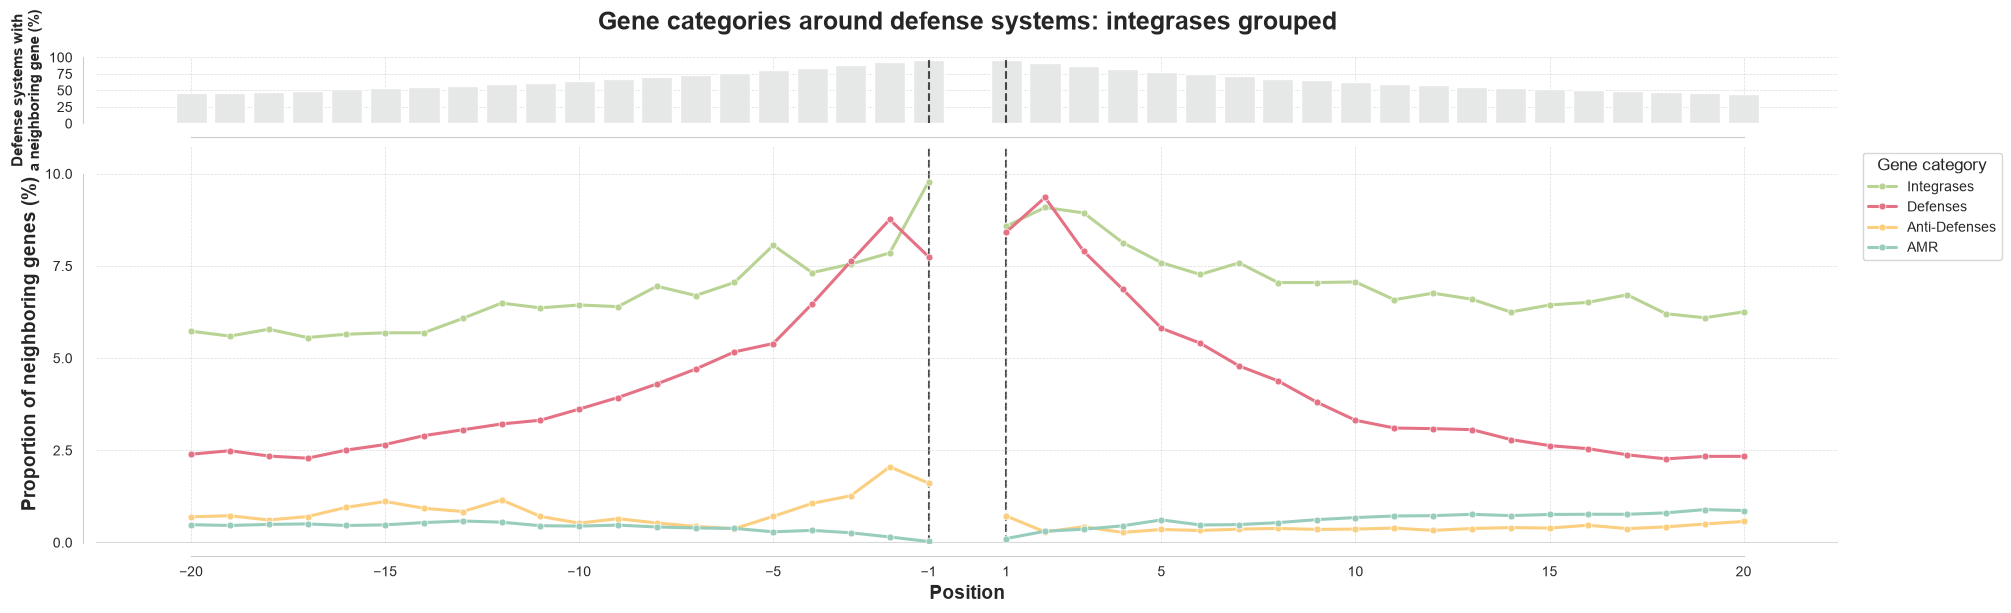

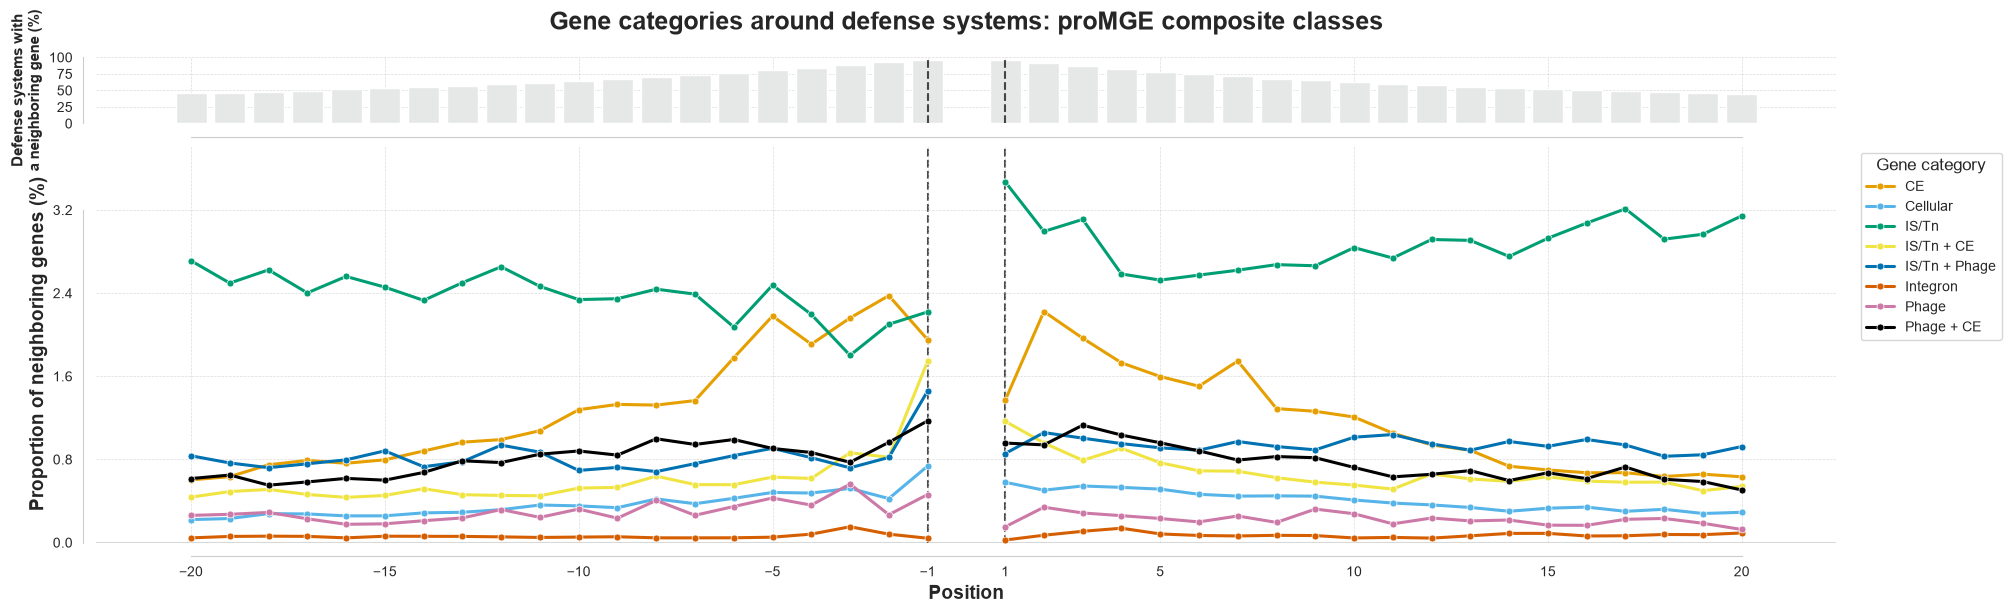

In [4]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns

BASE_CATEGORIES = ["Integrases", "Defenses", "Anti-Defenses", "AMR"]
COMPOSITE_CATEGORIES = sorted(PROMGE_COMPOSITE_CLASSES)
CATEGORY_MODES = {
    "grouped": BASE_CATEGORIES,
    "composite": COMPOSITE_CATEGORIES,
}


def is_excluded_defense(label, exclude_hok_sok_mazef):
    if pd.isna(label):
        return False
    normalized = str(label).strip().casefold()
    if exclude_hok_sok_mazef and normalized in {"hok/sok", "mazef"}:
        return True
    return False


def build_position_category_counts(
    dicc,
    integrase_mode="grouped",
    exclude_hok_sok_mazef=True,
):
    """Count annotated neighboring genes by position and plotting category."""
    if integrase_mode not in CATEGORY_MODES:
        raise ValueError(f"Unknown integrase_mode: {integrase_mode}")
    categories = CATEGORY_MODES[integrase_mode]
    rows = []

    for position in POSITIONS:
        payload = dicc[position]
        integrases = payload.get("integrase_type", [])
        defenses = payload.get("merged_type", [])
        anti_defenses = payload.get("Antidefense_type", [])
        amr_genes = payload.get("Gene_symbol", [])

        row = {
            "position": position,
            "n_total": len(payload.get("prot_id", [])),
            "Defenses": sum(
                pd.notna(value)
                and not is_excluded_defense(
                    value, exclude_hok_sok_mazef
                )
                for value in defenses
            ),
            "Anti-Defenses": sum(pd.notna(value) for value in anti_defenses),
            "AMR": sum(pd.notna(value) for value in amr_genes),
        }

        if integrase_mode == "composite":
            assigned_classes = [
                promge_composite_class(value)
                for value in integrases
                if pd.notna(value)
            ]
            class_counts = Counter(
                class_name for class_name in assigned_classes if class_name is not None
            )
            row.update(
                {
                    category: class_counts[category]
                    for category in PROMGE_COMPOSITE_CLASSES
                }
            )
        else:
            row["Integrases"] = sum(pd.notna(value) for value in integrases)

        rows.append(row)

    return pd.DataFrame(rows), categories


def plot_gene_proportions_lineplot(
    dicc,
    coverage,
    integrase_mode="grouped",
    palette=None,
    save_path=None,
    title=None,
    exclude_hok_sok_mazef=True,
    ylim=None,
):
    """Plot each category as a percentage of all neighboring genes."""
    counts, categories = build_position_category_counts(
        dicc,
        integrase_mode=integrase_mode,
        exclude_hok_sok_mazef=exclude_hok_sok_mazef,
    )
    data = counts[["position"]].copy()
    denominator = counts["n_total"].replace(0, np.nan)
    for category in categories:
        data[category] = (100 * counts[category] / denominator).fillna(0)

    if palette is None:
        palette = sns.color_palette("colorblind", len(categories))
    color_map = dict(zip(categories, palette))
    upstream = data[data["position"] < 0]
    downstream = data[data["position"] > 0]

    coverage_upstream = coverage[coverage["position"] < 0]
    coverage_downstream = coverage[coverage["position"] > 0]

    sns.set_style("whitegrid")
    fig, (coverage_ax, ax) = plt.subplots(
        2,
        1,
        figsize=(20, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [0.5, 3]},
        constrained_layout=True,
    )
    for segment in (coverage_upstream, coverage_downstream):
        coverage_ax.bar(
            segment["position"],
            segment["coverage_pct"],
            width=0.8,
            color="#E6E7E7",
        )
    coverage_ax.axvline(-1, color="black", linestyle="--", alpha=0.7)
    coverage_ax.axvline(1, color="black", linestyle="--", alpha=0.7)
    coverage_ax.set_ylabel(
        "Defense systems with\na neighboring gene (%)",
        fontsize=11,
        fontweight="bold",
    )
    coverage_ax.set_ylim(0, 100)
    coverage_ax.yaxis.set_major_locator(ticker.MultipleLocator(25))
    coverage_ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)
    coverage_ax.set_title(
        title or "Proportional distribution of gene categories",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )

    ax.axhline(0, color="gray", alpha=0.3, zorder=0)
    ax.axvline(-1, color="black", linestyle="--", alpha=0.7, zorder=0)
    ax.axvline(1, color="black", linestyle="--", alpha=0.7, zorder=0)

    for category in categories:
        color = color_map[category]
        for segment, label in ((upstream, category), (downstream, "_nolegend_")):
            ax.plot(
                segment["position"],
                segment[category],
                color=color,
                marker="o",
                linewidth=2.2,
                markersize=5,
                markeredgecolor="white",
                markeredgewidth=0.5,
                alpha=1.0,
                label=label,
            )

    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.set_xticks(
        [*range(-WINDOW, -1, 5), -1, 1, *range(5, WINDOW + 1, 5)]
    )
    ax.set_xlabel("Position", fontsize=14, fontweight="bold")
    ax.set_ylabel("Proportion of neighboring genes (%)", fontsize=14, fontweight="bold")
    ax.legend(
        title="Gene category",
        fontsize=10,
        title_fontsize=12,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        frameon=True,
    )
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.grid(False, which="minor")
    if ylim is None:
        observed_max = float(data[categories].to_numpy().max())
        upper_limit = max(1.0, observed_max * 1.10)
        ax.set_ylim(0, upper_limit)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, min_n_ticks=3))
    else:
        ax.set_ylim(ylim)
    sns.despine(ax=coverage_ax, offset=10, trim=True)
    sns.despine(ax=ax, offset=10, trim=True)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax, data


GROUPED_CATEGORY_COLORS = {
    "Defenses": "#E47184",
    "Anti-Defenses": "#FBCF7F",
    "AMR": "#98CCBD",
    "Integrases": "#B8D393",
}

fig_grouped, ax_grouped, grouped_plot_data = plot_gene_proportions_lineplot(
    final_dicts_stranded["defense"],
    neighbor_coverage,
    integrase_mode="grouped",
    palette=[GROUPED_CATEGORY_COLORS[category] for category in BASE_CATEGORIES],
    save_path="plots/fig06_A.pdf",
    title="Gene categories around defense systems: integrases grouped",
    exclude_hok_sok_mazef=True,
)

OKABE_ITO_PALETTE = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]

fig_composite, ax_composite, composite_plot_data = plot_gene_proportions_lineplot(
    final_dicts_stranded["defense"],
    neighbor_coverage,
    integrase_mode="composite",
    palette=OKABE_ITO_PALETTE[:len(COMPOSITE_CATEGORIES)],
    save_path="plots/figS17.pdf",
    title="Gene categories around defense systems: proMGE composite classes",
    exclude_hok_sok_mazef=True,
)


In [5]:
from scipy.stats import fisher_exact, norm


def _bh_fdr(pvals):
    """Benjamini-Hochberg FDR correction implemented with NumPy only."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    if m == 0:
        return np.array([])

    order = np.argsort(pvals)
    ranked = pvals[order]
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    out = np.empty(m)
    out[order] = adjusted
    return out


def _odds_ratio_ci(table, confidence_level=0.95):
    """Return a log-scale Wald CI, correcting zero cells by 0.5."""
    cells = np.asarray(table, dtype=float)
    if np.any(cells == 0):
        cells = cells + 0.5

    near_hit, near_miss = cells[0]
    far_hit, far_miss = cells[1]
    log_odds_ratio = np.log(
        (near_hit * far_miss) / (near_miss * far_hit)
    )
    standard_error = np.sqrt(np.sum(1 / cells))
    z_score = norm.ppf(0.5 + confidence_level / 2)
    return (
        np.exp(log_odds_ratio - z_score * standard_error),
        np.exp(log_odds_ratio + z_score * standard_error),
    )


def test_adjacency_enrichment(
    dicc,
    near_window=ENRICHMENT_WINDOW,
    context_window=ENRICHMENT_CONTEXT_WINDOW,
    integrase_mode="grouped",
    exclude_hok_sok_mazef=True,
):
    """
    Test whether categories are enriched near defense anchors.

    Near: |position| <= near_window
    Far/background: near_window < |position| <= context_window
    Input is restricted to anchors with a full context_window neighborhood.

    Uses two-sided Fisher exact tests, 95% log-OR
    confidence intervals, and BH-FDR correction.
    """
    counts, categories = build_position_category_counts(
        dicc,
        integrase_mode=integrase_mode,
        exclude_hok_sok_mazef=exclude_hok_sok_mazef,
    )
    counts = counts[
        (counts["position"] != 0)
        & (counts["position"].abs() <= context_window)
    ].copy()

    near = counts[counts["position"].abs() <= near_window]
    far = counts[counts["position"].abs() > near_window]

    results = []
    near_total = int(near["n_total"].sum())
    far_total = int(far["n_total"].sum())

    for category in categories:
        near_hits = int(near[category].sum())
        far_hits = int(far[category].sum())

        near_miss = near_total - near_hits
        far_miss = far_total - far_hits

        table = [[near_hits, near_miss], [far_hits, far_miss]]
        odds_ratio, p_value = fisher_exact(table, alternative="two-sided")
        odds_ratio_ci_low, odds_ratio_ci_high = _odds_ratio_ci(table)

        near_rate = near_hits / near_total if near_total else np.nan
        far_rate = far_hits / far_total if far_total else np.nan
        fold_enrichment = near_rate / far_rate if (pd.notna(far_rate) and far_rate > 0) else np.nan

        results.append(
            {
                "category": category,
                "near_hits": near_hits,
                "near_total": near_total,
                "near_rate": near_rate,
                "far_hits": far_hits,
                "far_total": far_total,
                "far_rate": far_rate,
                "odds_ratio": odds_ratio,
                "odds_ratio_ci_low": odds_ratio_ci_low,
                "odds_ratio_ci_high": odds_ratio_ci_high,
                "fold_enrichment": fold_enrichment,
                "p_value": p_value,
            }
        )

    out = pd.DataFrame(results)
    out["q_value_bh"] = _bh_fdr(out["p_value"].values)
    out = out.sort_values(["q_value_bh", "p_value"]).reset_index(drop=True)

    return counts, out


def format_enrichment_table(results, analysis):
    """Format proportions as percentages while retaining exact test outputs."""
    display_table = results.copy()
    display_table.insert(0, "analysis", analysis)
    display_table["near_rate_pct"] = 100 * display_table["near_rate"]
    display_table["far_rate_pct"] = 100 * display_table["far_rate"]
    return display_table[
        [
            "analysis",
            "category",
            "near_hits",
            "near_total",
            "near_rate_pct",
            "far_hits",
            "far_total",
            "far_rate_pct",
            "fold_enrichment",
            "odds_ratio",
            "odds_ratio_ci_low",
            "odds_ratio_ci_high",
            "p_value",
            "q_value_bh",
        ]
    ]


grouped_position_counts, grouped_enrichment_results = test_adjacency_enrichment(
    enrichment_dicts_stranded["defense"],
    near_window=ENRICHMENT_WINDOW,
    context_window=ENRICHMENT_CONTEXT_WINDOW,
    integrase_mode="grouped",
    exclude_hok_sok_mazef=True,
)

composite_position_counts, composite_enrichment_results = test_adjacency_enrichment(
    enrichment_dicts_stranded["defense"],
    near_window=ENRICHMENT_WINDOW,
    context_window=ENRICHMENT_CONTEXT_WINDOW,
    integrase_mode="composite",
    exclude_hok_sok_mazef=True,
)

expected_near_total = (
    enrichment_context_anchor_count * 2 * ENRICHMENT_WINDOW
)
expected_far_total = (
    enrichment_context_anchor_count
    * 2
    * (ENRICHMENT_CONTEXT_WINDOW - ENRICHMENT_WINDOW)
)
for results in [
    grouped_enrichment_results,
    composite_enrichment_results,
]:
    assert results["near_total"].eq(expected_near_total).all()
    assert results["far_total"].eq(expected_far_total).all()

enrichment_display = pd.concat(
    [
        format_enrichment_table(grouped_enrichment_results, "integrases grouped"),
        format_enrichment_table(composite_enrichment_results, "proMGE composite classes"),
    ],
    ignore_index=True,
)
enrichment_display

,analysis,category,near_hits,near_total,near_rate_pct,far_hits,far_total,far_rate_pct,fold_enrichment,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high,p_value,q_value_bh
0,integrases grouped,Integrases,32895,385950,8.523125,75878,1157850,6.553353,1.300575,1.328580,1.310785,1.346617,0.000000e+00,0.000000e+00
1,integrases grouped,Defenses,23123,385950,5.991191,30588,1157850,2.641793,2.267850,2.348650,2.307942,2.390077,0.000000e+00,0.000000e+00
2,integrases grouped,Anti-Defenses,6301,385950,1.632595,7859,1157850,0.678758,2.405268,2.428591,2.348944,2.510939,0.000000e+00,0.000000e+00
3,integrases grouped,AMR,1772,385950,0.459127,9128,1157850,0.788358,0.582384,0.580458,0.551591,0.610835,1.174217e-108,1.174217e-108
4,proMGE composite classes,IS/Tn + Phage,5934,385950,1.537505,12527,1157850,1.081919,1.421090,1.427666,1.383943,1.472770,1.167318e-106,9.338543e-106
5,proMGE composite classes,IS/Tn,15762,385950,4.083949,39586,1157850,3.418923,1.194513,1.202795,1.180359,1.225659,2.657319e-80,1.062928e-79
6,proMGE composite classes,Cellular,2108,385950,0.546185,4068,1157850,0.351341,1.554572,1.557618,1.477619,1.641948,6.458785e-58,1.722343e-57
7,proMGE composite classes,IS/Tn + CE,2835,385950,0.734551,6187,1157850,0.534352,1.374657,1.377429,1.317344,1.440255,3.279197e-43,6.558394e-43
8,proMGE composite classes,Phage + CE,2149,385950,0.556808,4610,1157850,0.398152,1.398482,1.400713,1.330636,1.474480,2.525668e-36,4.041069e-36
9,proMGE composite classes,Phage,1406,385950,0.364296,2915,1157850,0.251760,1.446998,1.448633,1.359172,1.543981,8.781369e-29,1.170849e-28


In [6]:
# Follow-up: composition of identified integrases near defense systems.
near_integrase_group_counts = (
    composite_position_counts.loc[
        composite_position_counts["position"].abs() <= ENRICHMENT_WINDOW,
        COMPOSITE_CATEGORIES,
    ]
    .sum()
    .reindex(COMPOSITE_CATEGORIES)
    .astype(int)
)

near_positions = [
    position
    for position in POSITIONS
    if 0 < abs(position) <= ENRICHMENT_WINDOW
]
total_integrases_near_defenses = sum(
    sum(
        pd.notna(value)
        for value in enrichment_dicts_stranded["defense"][position].get(
            "integrase_type", []
        )
    )
    for position in near_positions
)

assert near_integrase_group_counts.sum() <= total_integrases_near_defenses

integrase_group_percentages_near_defenses = (
    near_integrase_group_counts
    .rename("integrase_count")
    .rename_axis("integrase_group")
    .reset_index()
)
integrase_group_percentages_near_defenses[
    "total_integrases_near_defenses"
] = total_integrases_near_defenses
integrase_group_percentages_near_defenses[
    "percentage_of_integrases_near_defenses"
] = np.where(
    total_integrases_near_defenses > 0,
    100
    * integrase_group_percentages_near_defenses["integrase_count"]
    / total_integrases_near_defenses,
    np.nan,
)

integrase_group_percentages_near_defenses


,integrase_group,integrase_count,total_integrases_near_defenses,percentage_of_integrases_near_defenses
0,CE,2225,32895,6.763946
1,Cellular,2108,32895,6.408269
2,IS/Tn,15762,32895,47.916097
3,IS/Tn + CE,2835,32895,8.618331
4,IS/Tn + Phage,5934,32895,18.039216
5,Integron,476,32895,1.447028
6,Phage,1406,32895,4.274206
7,Phage + CE,2149,32895,6.532908
